## 2.1 Imputing, Encoding and First Pipeline

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, classification_report, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from features import *
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb


data = pd.read_csv('train.csv')
child_feature(data)
family_size_feature(data)
name_feature(data)
group_rare_title(data)
has_cabin_features(data)
fare_per_person_features(data)

In [27]:
X = data.drop(columns=['Survived', 'Ticket', 'PassengerId', 'Name', 'Cabin'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Child,FamilySize,Title,HasCabin,FarePerPerson
0,3,male,22.0,1,0,7.2500,S,0,2,Mr,0,3.62500
1,1,female,38.0,1,0,71.2833,C,0,2,Mrs,1,35.64165
2,3,female,26.0,0,0,7.9250,S,0,1,Miss,0,7.92500
3,1,female,35.0,1,0,53.1000,S,0,2,Mrs,1,26.55000
4,3,male,35.0,0,0,8.0500,S,0,1,Mr,0,8.05000


### Categorical and numerical features

In [31]:
cat_features = list(X.drop(columns=X.select_dtypes(include=['int', 'float'])))
num_features = [f for f in list(X.drop(columns=X.select_dtypes(include=['str']))) if f not in ['HasCabin', 'FarePerPerson']]

### Numerical and categorical pipeline + Imputer

In [4]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

### ColumnTransfer

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

### LogisticRegression Pipeline

In [6]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(C=1.0, max_iter=1000))
])

final_pipeline.fit(X_train, y_train)
prediction = final_pipeline.predict(X_test)

### Confusion Matrix, predict_proba, precision, recall

In [7]:
conf_matrix = confusion_matrix(y_test, prediction)
print(conf_matrix)

proba_survived = final_pipeline.predict_proba(X_test)[:, 1]
new_labels = (proba_survived >= 0.7).astype(int)

new_conf_matrix = confusion_matrix(y_test, new_labels)
print(new_conf_matrix)

[[89 16]
 [21 53]]
[[96  9]
 [34 40]]


### Important to mention:
 - 1. We have to increase recall because it is better to indentify person as dead and he is not than identify person as alive and he is dead

### Cross Validation

In [8]:
cross_validation = cross_val_score(final_pipeline, X, y, cv=5)
print(np.mean(cross_validation))

crv_predict = cross_val_predict(final_pipeline, X, y, cv=5)
conf_matrix = confusion_matrix(y, crv_predict)
print(conf_matrix)

class_report = classification_report(y, crv_predict)
print(class_report)

0.821542903772519
[[480  69]
 [ 90 252]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       549
           1       0.79      0.74      0.76       342

    accuracy                           0.82       891
   macro avg       0.81      0.81      0.81       891
weighted avg       0.82      0.82      0.82       891



### Class imbalance affects performance

 According to classification report we can see that results from the 0 class (death people) is higher than 1 class (survived)acros all three metrics - precision (0.83 vs 0.76), recall (0.86 vs 0.71), f1-score (0.84 vs 0.73). This is caused by more instances from class 0 (549 vs 342).

### DecisionTree vs RandomForest vs LogReg vs XGBoost

In [9]:
models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=42)),
    ('XGBoost', xgb.XGBClassifier(random_state=42)),
]

results = []

for name, model in models:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    cross_predict = cross_val_predict(pipeline, X, y, cv=5)
    precision = precision_score(y, cross_predict, average=None)
    recall = recall_score(y, cross_predict, average=None)
    f1 = f1_score(y, cross_predict, average=None)
    model_results = {
        'model': name,
        'accuracy': accuracy_score(y, cross_predict),
        'precision_dead': precision[0],
        'precision_survived': precision[1],
        'recall_dead': recall[0],
        'recall_survived': recall[1],
        'f1_dead': f1[0],
        'f1_survived': f1[1],
    }
    results.append(model_results)
df_results = pd.DataFrame(results)
df_results.head()

,model,accuracy,precision_dead,precision_survived,recall_dead,recall_survived,f1_dead,f1_survived
0,LogisticRegression,0.821549,0.842105,0.785047,0.874317,0.736842,0.857909,0.760181
1,DecisionTreeClassifier,0.777778,0.816216,0.714286,0.825137,0.701754,0.820652,0.707965
2,RandomForestClassifier,0.810325,0.833333,0.769470,0.865209,0.722222,0.848972,0.745098
3,XGBoost,0.810325,0.841727,0.758209,0.852459,0.742690,0.847059,0.750369


### RandomForest Vs DecisionTree

 - EnsembleMethods that is RandomForest is better than single tree because, when we are using just one tree we have only one estimator to evaluate our problem and this tree is very weak in generalizing new samples, so we rather use RandomForest, because in this method we are using for example 100, 200 or 250 different estimators (single trees) to evaluate our predictions. Moreover, RandomForest uses bagging that is randomly picking samples for one tree and then return this sample to our dataset, then we also randomly picking features to split our data. Always some data won't be picked so this samples called out-of-bag samples (37%). EnsembleMethods also have a method called pasting that is the same as bagging with one difference, that is randomly picking samples without returning. In our project single tree scored (76.77%) accuraccy vs RandomForest (80.70) that is a 4 point improvement.

### GridSearch RandomForest

In [10]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42)),
])

param_grid = {
    'model__n_estimators': [200, 220, 250, 270],
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 5, 6, 7],
    'model__min_samples_split': [10, 12, 14, 16],
    'model__min_samples_leaf': [4, 5, 6],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

new_results = {
    'model': f"Random Forest (Best: {grid_search.best_params_})",
    'accuracy': accuracy_score(y_test, y_pred),
    'precision_dead': precision[0],
    'precision_survived': precision[1],
    'recall_dead': recall[0],
    'recall_survived': recall[1],
    'f1_dead': f1[0],
    'f1_survived': f1[1],
}

results.append(new_results)
df_results = pd.DataFrame(results)
df_results.head()

,model,accuracy,precision_dead,precision_survived,recall_dead,recall_survived,f1_dead,f1_survived
0,LogisticRegression,0.821549,0.842105,0.785047,0.874317,0.736842,0.857909,0.760181
1,DecisionTreeClassifier,0.777778,0.816216,0.714286,0.825137,0.701754,0.820652,0.707965
2,RandomForestClassifier,0.810325,0.833333,0.769470,0.865209,0.722222,0.848972,0.745098
3,XGBoost,0.810325,0.841727,0.758209,0.852459,0.742690,0.847059,0.750369
4,Random Forest (Best: {'model__criterion': 'ent...,0.810056,0.814159,0.803030,0.876190,0.716216,0.844037,0.757143


In [11]:
print(f"RandomForest: {grid_search.best_score_}")
print(f1_score(y_test, y_pred, average='weighted'))

RandomForest: 0.8357726416919917
0.8081141041317352


### GridSerach XGBoost

In [12]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(random_state=42)),
])

xgb_param_grid = {
    'model__n_estimators': [180, 200, 220, 240],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.05, 0.07, 0.1, 0.15],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
)

xgb_grid_search.fit(X_train, y_train)
xgb_best_model = xgb_grid_search.best_estimator_
xgb_y_pred = xgb_best_model.predict(X_test)
xgb_precision = precision_score(y_test, xgb_y_pred, average=None)
xgb_recall = recall_score(y_test, xgb_y_pred, average=None)
xgb_f1 = f1_score(y_test, xgb_y_pred, average=None)

xgb_new_results = {
    'model': f"XGBoost (Best: {xgb_grid_search.best_params_})",
    'accuracy': accuracy_score(y_test, xgb_y_pred),
    'precision_dead': xgb_precision[0],
    'precision_survived': xgb_precision[1],
    'recall_dead': xgb_recall[0],
    'recall_survived': xgb_recall[1],
    'f1_dead': xgb_f1[0],
    'f1_survived': xgb_f1[1],
}

In [13]:
print(f"XGB: {xgb_grid_search.best_score_}")
print(f1_score(y_test, xgb_y_pred, average='weighted'))

XGB: 0.8312903789509993
0.8150336036639797


In [14]:
results.append(xgb_new_results)
df_results = pd.DataFrame(results)
df_results.head(10)

,model,accuracy,precision_dead,precision_survived,recall_dead,recall_survived,f1_dead,f1_survived
0,LogisticRegression,0.821549,0.842105,0.785047,0.874317,0.736842,0.857909,0.760181
1,DecisionTreeClassifier,0.777778,0.816216,0.714286,0.825137,0.701754,0.820652,0.707965
2,RandomForestClassifier,0.810325,0.833333,0.769470,0.865209,0.722222,0.848972,0.745098
3,XGBoost,0.810325,0.841727,0.758209,0.852459,0.742690,0.847059,0.750369
4,Random Forest (Best: {'model__criterion': 'ent...,0.810056,0.814159,0.803030,0.876190,0.716216,0.844037,0.757143
5,"XGBoost (Best: {'model__learning_rate': 0.07, ...",0.815642,0.833333,0.788732,0.857143,0.756757,0.845070,0.772414


### XGBoost Vs RandomForest

 - XGBoost with tuning is a slightly better than RandomForest also with tuning (0.8373 vs 0.8353)
  - The small gap is expected on this dataset: the strongest signals (sex, class) are simple and clear, so both bagging and boosting capture them almost equally well - there is not much "hard residual signals" left for boosting to exploit

### RandomForest Best Model

In [15]:
clean_params = {k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(**clean_params, random_state=42)),
])
final_model.fit(X, y)

test_data = pd.read_csv("test.csv")
child_feature(test_data)
family_size_feature(test_data)
name_feature(test_data)
group_rare_title(test_data)
has_cabin_features(test_data)
fare_per_person_features(test_data)

passenger_id = test_data['PassengerId']
test_data = test_data.drop(columns=['PassengerId', 'Ticket', 'Name', 'Cabin'])

predictions = final_model.predict(test_data)

submission = {
    'PassengerId': passenger_id,
    'Survived': predictions,
}

submission_data_frame = pd.DataFrame(submission)
submission_data_frame.to_csv("submission.csv", index=False)

### Kaggle Submission:
 - First Model RandomForest with GridSearch - 0.77751

### Evaluating model and data

In [16]:
error_predictions = cross_val_predict(final_model, X, y, cv=5)
error_analysis = data.copy()

error_analysis['Predictions'] = error_predictions
error_analysis['is_correct'] = (error_analysis['Survived'] == error_analysis['Predictions'])
error_analysis.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Child,FamilySize,Title,HasCabin,FarePerPerson,Predictions,is_correct
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,Mr,0,3.62500,0,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,2,Mrs,1,35.64165,1,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,Miss,0,7.92500,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2,Mrs,1,26.55000,1,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,Mr,0,8.05000,0,True


In [17]:
error_analysis['is_correct'].sum()

np.int64(736)

In [18]:
pd.crosstab(error_analysis['Pclass'], error_analysis['is_correct'], normalize='index') * 100

is_correct,False,True
Pclass,,
1,22.685185,77.314815
2,7.608696,92.391304
3,18.737271,81.262729


In [19]:
pd.crosstab(error_analysis['Sex'], error_analysis['is_correct'], normalize='index') * 100

is_correct,False,True
Sex,,
female,19.426752,80.573248
male,16.291161,83.708839


In [20]:
pd.crosstab(error_analysis['Child'], error_analysis['is_correct'], normalize='index') * 100

is_correct,False,True
Child,,
0,18.094089,81.905911
1,8.064516,91.935484


In [21]:
pd.crosstab([data['Pclass'], data['Sex']], data['Survived'], normalize='index') * 100

Survived               0          1
Pclass Sex                         
1      female   3.191489  96.808511
       male    63.114754  36.885246
2      female   7.894737  92.105263
       male    84.259259  15.740741
3      female  50.000000  50.000000
       male    86.455331  13.544669

In [22]:
data.groupby(['Pclass', 'Sex']).size()

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

### Conclusions:

 - Children 'age < 10' are classified almost deterministically (90.3%)
 - Men are generally better classified than women (84.2% vs 80.3%) because rule 'men' -> death is more unequivocal than 'women' -> survived, so there is less exceptions that model can miss
 - Class 1 has the lowest accuracy (78.2%) despite having the highest overall survival rate this is because its largest subgroup, men (56.5% of the class) exhibits a markedly less clear-cut survival pattern (63/37) than men in classes 2–3 (84–86% mortality); Class 3, while also containing an equally ambiguous subgroup (women, 50/50), is less affected by it, as that group constitutes only 29% of the class.

### ROC curve

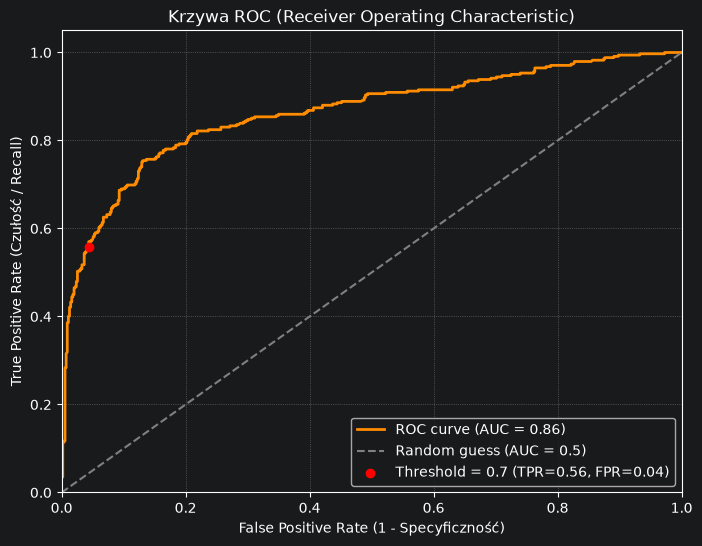

In [23]:
crs_val_predict = cross_val_predict(final_pipeline, X, y, cv=5, method='predict_proba')
positive_class_probs = crs_val_predict[:, 1]

fpr, tpr, thresholds = roc_curve(y, positive_class_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess (AUC = 0.5)')
idx = np.argmin(np.abs(thresholds - 0.7))
plt.scatter(fpr[idx], tpr[idx], color='red', zorder=5, label=f'Threshold = 0.7 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specyficzność)')
plt.ylabel('True Positive Rate (Czułość / Recall)')
plt.title('Krzywa ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Conclusions ROC Curve & AUC

Instead of looking at single threshold (like the 0.7 we picked in T1), the ROC curve shows how the model's True Positive Rate (TPR, i.e. recall for "survived") and False Positive Rate (FPR) change across *every possible* threshold from 0 to 1.

**Shape vs. random guessing:** the curve sits clearly above the diagonal line (which represents a model with no predictive power, AUC = 0.5) across its entire range. This confirms the model is genuinely separating the two classes, not guessing randomly.

**AUC = 0.86:** this single number summarizes the whole curve — it's the probability that, given one random survivor and one random non-survivor, the model assigns a higher survival probability to the actual survivor. An AUC well above 0.5 (and reasonably close to 1.0) confirms strong overall discriminative power, independent of any specific threshold choice.

**Connecting back to T1's threshold = 0.7:** the marked point on the curve (FPR = 0.04, TPR = 0.56) is the same experiment from T1, just viewed from the opposite class's perspective. Since FPR = 1 - recall(died), our T1 recall for "died" (0.962) directly explains today's low FPR (0.038 ≈ 0.04). The TPR (0.56) is recall for "survived" — a number we didn't compute directly in T1, but it shows the cost of raising the threshold: by making the model more cautious about predicting "survived" (to better catch deaths), we sacrifice correctly identifying survivors. Today's ROC curve makes this same precision/recall trade-off from T1 visible as a full spectrum, rather than a single data point.

### XGBoost Best Model (Different Features)

In [32]:
xgb_clean_params = {k.replace('model__', ''): v for k, v in xgb_grid_search.best_params_.items()}

def score_with_feature(num_features):
    preprocessor = ColumnTransformer([
        ('num' , num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(**xgb_clean_params, random_state=42))
    ])

    return cross_val_score(pipeline, X, y, cv=5).mean()

In [34]:
print(f"Base acc: {score_with_feature(num_features)}")
print(f"Acc without FamilySize: {score_with_feature([f for f in num_features if f != 'FamilySize'])}")
print(f"Acc with HasCabin: {score_with_feature(num_features + ['HasCabin'])}")
print(f"Acc with Fare Per Person: {score_with_feature(num_features + ['FarePerPerson'])}")

Base acc: 0.8271608813006089
Acc without FamilySize: 0.8282844768062269
Acc with HasCabin: 0.8316427091833531
Acc with Fare Per Person: 0.8294080723118448
